# LISARDD: PPO for latent Molecular Reinforcement Learning Optimization

## Imports and installs

In [ ]:
!pip install rdkit torch_geometric

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.optim.lr_scheduler as lr_scheduler
from torch.distributions import MultivariateNormal
from torch.utils.data import DataLoader

import math, random, sys
import numpy as np
import argparse
from tqdm import tqdm

from hgraph import *
import rdkit
from rdkit import Chem
from multiprocessing import Pool, cpu_count
import time

from types import SimpleNamespace

from score_model import MGraphDTA #note that this is the only file that we need in this repo

from rdkit.Chem import ChemicalFeatures
from rdkit import RDConfig
import networkx as nx
import os.path as osp
from torch_geometric.data import Data, Batch
from rdkit.Contrib.SA_Score import sascorer
from rdkit.Chem import QED #need the rdkit before chem

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1TlGu9T7WLlq6pilIhqRykT2-3XfgslLX/HG2G
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.8 MB/s eta 0:00:00
Using device: cuda


## Loading HierVAE model

In [ ]:
path_to_chembl = "data/chembl/"
path_to_vocab = "recovered_vocab_2000.txt"
vocab = [x.strip("\r\n ").split() for x in open(path_to_chembl + path_to_vocab)]

vocab = PairVocab(vocab)

path_to_vae_model = "vae_model/vae_model.ckpt"
args = SimpleNamespace(
    vocab=vocab,
    atom_vocab=common_atom_vocab,
    model=path_to_vae_model,    # Path to your model checkpoint file

    seed=7,
    nsample=124,

    rnn_type='LSTM',
    hidden_size=250,
    embed_size=250,
    batch_size=128, #used to be 50
    latent_size=32,
    depthT=15,
    depthG=15,
    diterT=1,
    diterG=3,
    dropout=0.0
)

vae_model = HierVAE(args).cuda()
vae_model.load_state_dict(torch.load(args.model)[0])

/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))


<All keys matched successfully>

In [ ]:
#count model parameters:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(vae_model):,} parameters')

The model has 7,964,548 trainable parameters


## Loading the Scoring model

In [ ]:
VOCAB_PROTEIN = { "A": 1, "C": 2, "B": 3, "E": 4, "D": 5, "G": 6,
				"F": 7, "I": 8, "H": 9, "K": 10, "M": 11, "L": 12,
				"O": 13, "N": 14, "Q": 15, "P": 16, "S": 17, "R": 18,
				"U": 19, "T": 20, "W": 21,
				"V": 22, "Y": 23, "X": 24,
				"Z": 25 }

VOCAB_ATOMS = ['H', 'C', 'N', 'O', 'F', 'Cl', 'S', 'Br', 'I']

fdef_name = osp.join(RDConfig.RDDataDir, 'BaseFeatures.fdef')
chem_feature_factory = ChemicalFeatures.BuildFeatureFactory(fdef_name)

path_to_save = "scoring_model_weights/"
best_scoring_model = "best_scoring_model.pt"
path_to_scoring_model = path_to_save + best_scoring_model

scoring_model_weights = torch.load(path_to_scoring_model)

scoring_model = MGraphDTA(3,25+1,embedding_size=128,filter_num = 32,out_dim = 1).to("cuda")

try:
    scoring_model.load_state_dict(torch.load(path_to_scoring_model,map_location=torch.device('cuda')))
except:
    scoring_model_dict = torch.load(path_to_scoring_model, map_location=torch.device('cuda'))
    for key, val in scoring_model_dict.copy().items():
        if 'lin_l' in key:
            new_key = key.replace('lin_l', 'lin_rel')
            scoring_model_dict[new_key] = scoring_model_dict.pop(key)
        elif 'lin_r' in key:
            new_key = key.replace('lin_r', 'lin_root')
            scoring_model_dict[new_key] = scoring_model_dict.pop(key)
    scoring_model.load_state_dict(scoring_model_dict)

Utility functions to parse SMILES into scoring model graph inputs

In [ ]:
def smile_to_graph(smile: str):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smile}")

    feats = chem_feature_factory.GetFeaturesForMol(mol)
    g = nx.DiGraph()

    # Create nodes
    for i in range(mol.GetNumAtoms()):
        atom = mol.GetAtomWithIdx(i)
        g.add_node(i,
            a_type=atom.GetSymbol(),
            a_num=atom.GetAtomicNum(),
            acceptor=0,
            donor=0,
            aromatic=atom.GetIsAromatic(),
            hybridization=atom.GetHybridization(),
            num_h=atom.GetTotalNumHs(),
            ExplicitValence=atom.GetExplicitValence(),
            FormalCharge=atom.GetFormalCharge(),
            ImplicitValence=atom.GetImplicitValence(),
            NumExplicitHs=atom.GetNumExplicitHs(),
            NumRadicalElectrons=atom.GetNumRadicalElectrons()
        )

    for feat in feats:
        if feat.GetFamily() in ['Donor', 'Acceptor']:
            for idx in feat.GetAtomIds():
                g.nodes[idx][feat.GetFamily().lower()] = 1

    # Create edges
    for i in range(mol.GetNumAtoms()):
        for j in range(mol.GetNumAtoms()):
            bond = mol.GetBondBetweenAtoms(i, j)
            if bond is not None:
                g.add_edge(i, j,
                    b_type=bond.GetBondType(),
                    IsConjugated=int(bond.GetIsConjugated())
                )

    # Node features
    feat = []
    for n, d in g.nodes(data=True):
        h_t = []
        h_t += [int(d['a_type'] == x) for x in VOCAB_ATOMS]
        h_t.append(d['a_num'])
        h_t.append(d['acceptor'])
        h_t.append(d['donor'])
        h_t.append(int(d['aromatic']))
        h_t += [int(d['hybridization'] == x) for x in (
            Chem.rdchem.HybridizationType.SP,
            Chem.rdchem.HybridizationType.SP2,
            Chem.rdchem.HybridizationType.SP3
        )]
        h_t.append(d['num_h'])
        h_t += [
            d['ExplicitValence'],
            d['FormalCharge'],
            d['ImplicitValence'],
            d['NumExplicitHs'],
            d['NumRadicalElectrons']
        ]
        feat.append((n, h_t))
    feat.sort(key=lambda item: item[0])
    x = torch.FloatTensor([item[1] for item in feat])

    # Edge features
    e = {}
    for n1, n2, d in g.edges(data=True):
        e_t = [int(d['b_type'] == x) for x in (
            Chem.rdchem.BondType.SINGLE,
            Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE,
            Chem.rdchem.BondType.AROMATIC
        )]
        e_t.append(int(d['IsConjugated'] == False))
        e_t.append(int(d['IsConjugated'] == True))
        e[(n1, n2)] = e_t

    if len(e) == 0:
        edge_index = torch.LongTensor([[0], [0]])
        edge_attr = torch.FloatTensor([[0, 0, 0, 0, 0, 0]])
    else:
        edge_index = torch.LongTensor(list(e.keys())).T
        edge_attr = torch.FloatTensor(list(e.values()))

    # Normalize x as done in process_data
    if x.numel() > 0:
        x = (x - x.min()) / (x.max() - x.min())

    return x, edge_index, edge_attr

def seq_to_tensor(sequence, max_len=1200,device = "cuda"):
    seq = [VOCAB_PROTEIN.get(s, 0) for s in sequence]
    if len(seq) < max_len:
        seq = np.pad(seq, (0, max_len - len(seq)))
    else:
        seq = seq[:max_len]
    return torch.LongTensor(seq).to(device)

Utility function to compute rewards

In [ ]:
def predict_affinities_batched_pKd(score_model, smiles_batch, protein_seq, device='cuda'):
    """
    Predict affinities for a list of SMILES using batched inference.

    Returns:
        List of (smile, predicted_score) tuples.
    """
    data_list = []

    for smile in smiles_batch:
        try:
            x, edge_index, edge_attr = smile_to_graph(smile)
            target = seq_to_tensor(protein_seq).unsqueeze(0)

            data = Data(
                x=x, #feature matrix => atom-level
                edge_index=edge_index,# adjacency matrix
                edge_attr=edge_attr, #bond types
                target=target #protein
            )
            data_list.append((smile, data))

        except Exception as e:
            print(f"⚠️ Skipping SMILES")

    # Split into batches
    score_model.eval()
    # with torch.no_grad():
    smiles, graph_data = zip(*data_list)
    batch = Batch.from_data_list(graph_data).to(device)
    preds = score_model(batch)

    return preds

A few example proteins and ligands

In [ ]:
adenosine_receptor_sequence = "MPPSISAFQAAYIGIEVLIALVSVPGNVLVIWAVKVNQALRDATFCFIVSLAVADVAVGALVIPLAILINIGPQTYFHTCLMVACPVLILTQSSILALLAIAVDRYLRVKIPLRYKMVVTPRRAAVAIAGCWILSFVVGLTPMFGWNNLSAVERAWAANGSMGEPVIKCEFEKVISMEYMVYFNFFVWVLPPLLLMVLIYLEVFYLIRKQLNKKVSASSGDPQKYYGKELKIAKSLALILFLFALSWLPLHILNCITLFCPSCHKPSILTYIAIFLTHGNSAMNPIVYAFRIQKFRVTFLKIWNDHFRCQPAPPIDEDLPEERPDD"
adenosine_smiles = ["C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N"]

staurosporine_smiles = ["C[C@@]12[C@@H]([C@@H](C[C@@H](O1)N3C4=CC=CC=C4C5=C6C(=C7C8=CC=CC=C8N2C7=C53)CNC6=O)NC)OC"]
human_cyclin_dependent_kinase_seq = "MENFQKVEKIGEGTYGVVYKARNKLTGEVVALKKIRLDTETEGVPSTAIREISLLKELNHPNIVKLLDVIHTENKLYLVFEFLHQDLKKFMDASALTGIPLPLIKSYLFQLLQGLAFCHSHRVLHRDLKPQNLLINTEGAIKLADFGLARAFGVPVRTYTHEVVTLWYRAPEILLGCKYYSTAVDIWSLGCIFAEMVTRRALFPGDSEIDQLFRIFRTLGTPDEVVWPGVTSMPDYKPSFPKWARQDFSKVVPPLDEDGRSLLSQMLHYDPNKRISAKAALAHPFFQDVTKPVPHLRL"

streptavidin = "MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWYNQLGSTFIVTAGADGALTGTYESAVGNAESRYVLTGRYDSAPATDGSGTALGWTVAWKNNYRNAHSATTWSGQYVGGAEARINTQWLLTSGTTEANAWKSTLVGHDTFTKVKPSAASIDAAKKAGVNNGNPLDAVQQ"

## RL- Latent Space optimization

Actor-Critic Network definition from Haddad et al. 2025: R. Haddad, E. E. Litsa, Z. Liu, X. Yu, D. Burkhardt, and G. Bhisetti. Targeted molecular
generation with latent reinforcement learning. Scientific Reports, 15(1):15202, Apr. 2025. ISSN
2045-2322. doi: 10.1038/s41598-025-99785-0. Publisher: Nature Publishing Group.

In [ ]:
### RL-PPO
class SharedNetwork(nn.Module): # from Haddad et al 2025
    def __init__(self, latent_dim, hidden_dim=256):
        super(SharedNetwork, self).__init__()
        self.fc1 = nn.Linear(3*latent_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.fc2(x)))
        x = F.relu(self.bn3(self.fc3(x)))
        return x

class Actor(nn.Module):
    def __init__(self, shared_net, latent_dim, hidden_dim):
        super(Actor, self).__init__()
        self.shared_net = shared_net
        self.actor_entry = nn.Linear(shared_net.hidden_dim, hidden_dim)
        self.actor_head = nn.Linear(hidden_dim, 3*latent_dim)  # Output μ_1,μ_2,μ_3 => HierVAE latent space is R^32 x R^32 x R^32

    def forward(self, z):
        x = self.shared_net(z)
        u = F.relu(self.actor_entry(x))
        mu = torch.tanh(self.actor_head(u))
        return mu

class Critic(nn.Module):
    def __init__(self, shared_net, hidden_dim):
        super(Critic, self).__init__()
        self.shared_net = shared_net
        self.critic_fc1 = nn.Linear(shared_net.hidden_dim, hidden_dim)
        self.critic_fc2 = nn.Linear(hidden_dim, 1)  # Output scalar value

    def forward(self, z):
        x = self.shared_net(z)
        x = F.relu(self.critic_fc1(x))
        value = self.critic_fc2(x)
        return value

### DECODING FUNCTIONS
def decode_smiles_from_latent(decoder, z_batch):#z_batch = (z_1,z_2,z_3)
    decoded_smiles = decoder.decode(z_batch, greedy=True, max_decode_step=150)
    return decoded_smiles

def safe_decode_batch(decoder,z_batch): # a reccurrent problem with HierVAE: due to vocabulary limitations, the model might generate SMILES graphs that are impossible to decode.
    batch_size = z_batch[0].shape[0]
    try:
        smiles_batch = decode_smiles_from_latent(decoder,z_batch) # Try batch decode everything
        valid = [True] * len(smiles_batch)
    except: #if error triggered, typically KeyError due to one motif impossible to decode...
        smiles_batch = []
        valid = []
        for i in range(batch_size):
            z1,z2,z3 = z_batch[0][i],z_batch[1][i],z_batch[2][i]
            z_one_try = (z1.unsqueeze(0),z2.unsqueeze(0),z3.unsqueeze(0))
            try:
                smile = decode_smiles_from_latent(decoder, z_one_try)[0]  # ...decode one by one => might be a way to make this more efficient...
                smiles_batch.append(smile)
                valid.append(True)
            except:
                smiles_batch.append(None)
                valid.append(False)
    return smiles_batch, valid

### REWARDS
def compute_binding_affinity(score_model, smiles_batch, target_protein):
    rewards = predict_affinities_batched_pKd(score_model, smiles_batch, target_protein)
    return rewards

def sulfure_reward(smiles_batch):
    has_sulfure = torch.zeros(len(smiles_batch)).to(device)
    for i in range(len(smiles_batch)):
        mol = Chem.MolFromSmiles(smiles_batch[i])
        if mol is not None:
          for atom in mol.GetAtoms():
              if atom.GetSymbol() == 'S':
                  has_sulfure[i] = 1.
                  break
    return has_sulfure

def compute_prop_high_binders(score_model,smiles_batch,target_protein,low = 7, high = 14):
    rewards = predict_affinities_batched_pKd(score_model, smiles_batch, target_protein).squeeze(1)
    high_binders =1.0* ((rewards >= low) & (rewards <= high))
    return high_binders

def sa_and_qed_rewards(smiles_batch):
    sa = torch.zeros(len(smiles_batch)).to(device)
    qed = torch.zeros(len(smiles_batch)).to(device)
    for i in range(len(smiles_batch)):
      m = Chem.MolFromSmiles(smiles_batch[i])
      sa[i] = sascorer.calculateScore(m)
      qed[i] = QED.qed(m)
    return 1-sa*0.1, qed

### A memory class to store experiments
class Memory:
    def __init__(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.logprobs = []
        self.values = []

    def clear(self):
        self.states = []
        self.actions = []
        self.rewards = []
        self.logprobs = []
        self.values = []

Defining training parameters:

In [ ]:
#### PARAMETERS
latent_dim = 32
hidden_dim = 256

batch_size = 128
ppo_epochs = 6
clip_eps = 0.2
sigma_init = 0.5
gamma_sigma_decay = 0.9995

#### RL MODELS
shared_net = SharedNetwork(latent_dim=latent_dim,
                           hidden_dim=hidden_dim).to(device)
actor = Actor(shared_net = shared_net,
              latent_dim = latent_dim,
              hidden_dim=hidden_dim).to(device)
critic = Critic(shared_net=shared_net,
                hidden_dim=hidden_dim).to(device)

optimizer = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=1e-3)

# Initialize noise parameter
sigma = sigma_init
covariance_matrix = torch.eye(3*latent_dim).to(device) * sigma**2

memory = Memory()

####### EPOCH COUNT IS HERE #######
restart_every = 20  # Epochs
n_epochs = 100

######### TARGET PROTEIN UPDATE IS HERE ##########
target_protein = human_cyclin_dependent_kinase_seq
#target_protein = streptavidin

###### EMPTY LISTS TO STORE OUTPUTS
average_obj_scores = []
loss_actor_list = []
loss_critic_list = []

best_z_list = []
best_reward_list = []
N_best = np.min([n_epochs//4,100]) #top N molecules to store

penalty_value = -1.0

/usr/local/lib/python3.11/dist-packages/torch/_compile.py:32: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


Then, the actual main PPO loop:

In [ ]:
vae_model.eval()
scoring_model.eval()

# --- Before training ---
best_reward_ever = -float('inf')
best_z_batch = None

for epoch in tqdm(range(n_epochs)):
    w1,w2 = 0.1, 0.1 #feel free to change them
    actor.eval()
    critic.eval()
    # === 1. Sample initial latent points ===

    if epoch % restart_every == 0 and epoch != 0:
        if best_z_list:
            idx = np.random.randint(len(best_z_list))
            selected_best_z = best_z_list[idx]

            z_batch = selected_best_z.expand(batch_size, -1) + 0.05 * torch.randn(batch_size, 3*latent_dim).to(device)
            z_batch = z_batch.clone().detach()
        else:
            z_batch = torch.randn(batch_size, 3*latent_dim).to(device)
    else:
        z_batch = torch.randn(batch_size, 3*latent_dim).to(device)

    # === 2. Sample actions ===
    with torch.no_grad():
      mu = actor(z_batch)

    dist = MultivariateNormal(mu, covariance_matrix)
    actions = dist.sample()
    logprobs = dist.log_prob(actions)

    z_next = z_batch + actions

    # === 3. Decode and Evaluate ===
    z_next_to_decode = torch.chunk(z_next, 3, dim=1)
    smiles_batch, valid = safe_decode_batch(vae_model.decoder, z_next_to_decode)

    valid_mask = torch.tensor(valid, device=device, dtype=torch.bool)
    valid_smiles = [smile for smile, is_valid in zip(smiles_batch, valid) if is_valid]

    un_norm_rewards = torch.zeros(batch_size, device=device)
    un_norm_rewards[~valid_mask] = penalty_value

    ### Simple-objective reward functions:
    # un_norm_rewards[valid_mask] = compute_binding_affinity(scoring_model, valid_smiles, target_protein).squeeze(1)
    # un_norm_rewards[valid_mask] = sulfure_reward(valid_smiles)
    un_norm_rewards[valid_mask] = compute_prop_high_binders(scoring_model, valid_smiles, target_protein)

    ### Multi-objective reward function:
    #sa, qed = sa_and_qed_rewards(valid_smiles)
    #un_norm_rewards[valid_mask] = w1*sa + w2*qed + (1.0 - w1- w2)*compute_prop_high_binders(scoring_model, valid_smiles, target_protein)

    rewards = (un_norm_rewards - un_norm_rewards.mean()) / (un_norm_rewards.std() + 1e-8)  # Normalize rewards

    with torch.no_grad():
      values = critic(z_batch).squeeze()

    # === 4. Store Trajectories ===
    memory.states.append(z_batch.detach())
    memory.actions.append(actions.detach())
    memory.rewards.append(rewards.detach())
    memory.logprobs.append(logprobs.detach())
    memory.values.append(values.detach())

    # === 5. PPO Update ===
    actor.train()
    critic.train()

    states = torch.cat(memory.states)
    actions = torch.cat(memory.actions)
    rewards = torch.cat(memory.rewards)
    logprobs_old = torch.cat(memory.logprobs)
    values_old = torch.cat(memory.values)

    advantages = rewards - values_old

    for _ in range(ppo_epochs):
        mu = actor(states)
        dist = MultivariateNormal(mu, covariance_matrix)

        logprobs = dist.log_prob(actions)

        values = critic(states).squeeze()

        ratio = torch.exp(logprobs - logprobs_old) #probability ratio
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages

        loss_actor = -torch.min(surr1, surr2).mean()
        loss_critic = F.mse_loss(values, rewards)

        loss = loss_actor + 0.5 * loss_critic
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # === 6. Sigma Annealing ===
    sigma *= gamma_sigma_decay
    covariance_matrix = torch.eye(3*latent_dim).to(device) * sigma**2

    memory.clear()

    # Optional: Save best z found so far
    best_idx = un_norm_rewards.argmax()
    best_reward_now = un_norm_rewards[best_idx]
    best_z_now = z_next[best_idx:best_idx+1].clone().detach()

    # Add the new candidate
    best_z_list.append(best_z_now)
    best_reward_list.append(best_reward_now.item())

    # Keep only the top N best
    if len(best_z_list) > N_best:
      # Sort by reward
      sorted_indices = sorted(range(len(best_reward_list)), key=lambda i: best_reward_list[i], reverse=True)
      best_z_list = [best_z_list[i] for i in sorted_indices[:N_best]]
      best_reward_list = [best_reward_list[i] for i in sorted_indices[:N_best]]

    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Avg reward = {un_norm_rewards.mean().item():.4f}, Sigma = {sigma:.5f}, Loss Actor = {loss_actor.item():.4f}, Loss Critic = {loss_critic.item():.4f}")
    average_obj_scores.append(un_norm_rewards.mean().item())

    loss_actor_list.append(loss_actor.item()) #store actor loss
    loss_critic_list.append(loss_critic.item()) #store critic loss

  1%|          | 1/100 [00:06<10:23,  6.30s/it]

Epoch 0: Avg reward = 0.0078, Sigma = 0.49975, Loss Actor = -0.0285, Loss Critic = 0.5263


  6%|▌         | 6/100 [00:43<11:41,  7.47s/it]

Epoch 5: Avg reward = 0.0078, Sigma = 0.49850, Loss Actor = -0.0698, Loss Critic = 0.0628


 11%|█         | 11/100 [01:16<09:42,  6.54s/it]

...

 91%|█████████ | 91/100 [14:11<01:51, 12.36s/it]

Epoch 90: Avg reward = 0.0938, Sigma = 0.47775, Loss Actor = -0.1936, Loss Critic = 0.8652


 96%|█████████▌| 96/100 [15:13<00:48, 12.18s/it]

Epoch 95: Avg reward = 0.0312, Sigma = 0.47656, Loss Actor = -0.1404, Loss Critic = 0.8912


100%|██████████| 100/100 [16:02<00:00,  9.62s/it]


Then, some visualizations:

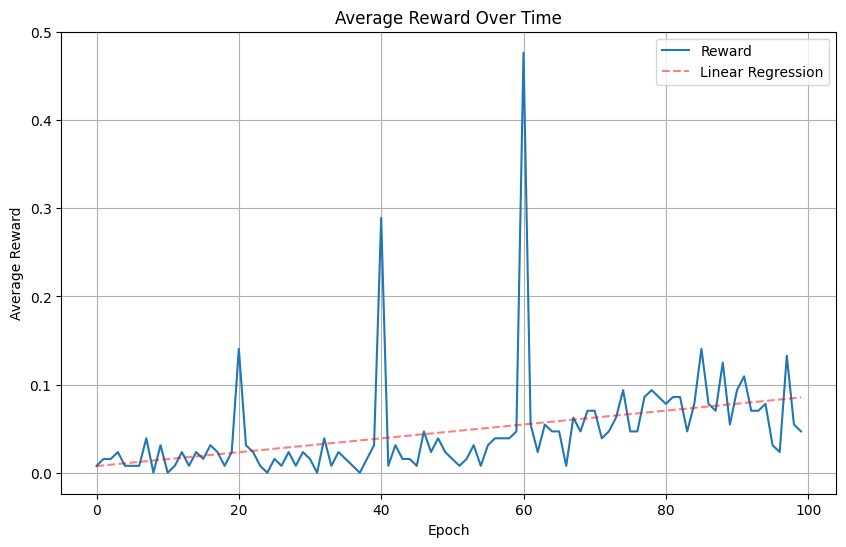

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
x = np.arange(len(average_obj_scores))
linreg = LinearRegression().fit(x.reshape(-1, 1), average_obj_scores)
y_pred = linreg.predict(x.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.plot(average_obj_scores, label = "Reward")
plt.plot(y_pred, linestyle='--', color='red', alpha=0.5, label='Linear Regression')
plt.xlabel('Epoch')
plt.ylabel('Average Reward')
plt.title('Average Reward Over Time')
plt.grid()
plt.legend()
plt.show()

## Validation

Retrieve highest scoring latent vectors, decode them into smiles and evaluate rewards on them.

In [ ]:
best_z_to_decode = [best_z.chunk(3, dim=1) for best_z in best_z_list]
best_z_1 = torch.cat([best_z_chunked[0] for best_z_chunked in best_z_to_decode],dim = 0)
best_z_2 = torch.cat([best_z_chunked[1] for best_z_chunked in best_z_to_decode],dim = 0)
best_z_3 = torch.cat([best_z_chunked[2] for best_z_chunked in best_z_to_decode],dim = 0)
best_smiles = decode_smiles_from_latent(vae_model.decoder, (best_z_1,best_z_2,best_z_3))

In [ ]:
best_smiles

['NC1C(c2cc(Cl)c(-c3ccccc3)c(C(F)(F)F)c2)=C1c1cccc([N+](=O)[O-])c1C(=O)c1ccccc1',
 'N=C(CCl)C1CCCCC12CCCCC2',
 'Cc1ccc([N+](=O)[O-])c(C)c1C',
 'Cc1c([NH+]=O)ccc([N+](=O)[O-])c1C=NC=NC1CCC1Cc1ccccc1',
 'C[NH+](C)c1ccc([NH3+])c(C(=O)Cc2ccccc2)c1[N+](=O)[O-]',
 'CC(C)C(=O)c1cc2ccccc2n1-c1cccc[n+]1[O-]',
 'CN1N=C(Cc2cccc[n+]2[O-])NC12NC=C([NH2+][O-])C([NH+](C)C)N2Cc1ccc([NH+](C)C)c[n+]1[O-]',
 'CC(C)C(=O)c1c([NH3+])cccc1[N+](=O)[O-]',
 'CCC(C)C(=O)c1c([N+](=O)[O-])ccc(C(=O)c2ccccc2)c1[N+](=O)[O-]',
 'CC(C)C(=O)c1c([N+](=O)[O-])cccc1[N+](=O)[O-]',
 'Cc1c([NH+](C)c2cc(-c3ccccc3)ccc2C(=O)c2ccccc2)ccc([N+](C)(C)c2ccccc2C(=O)c2ccccc2)c1[N+](=O)[O-]',
 'CNC(=O)C(Cc1c(C(=O)c2ccccc2[NH+](C)C)c([NH3+])cc(C)c1[NH+](C)C)C(=O)[O-]',
 'COC(C)C(=O)c1c([N+](=O)[O-])ccc([N+](=O)[O-])c1[N+](=O)[O-]',
 'CCC(=O)C(=O)C(=O)c1c([NH+](C)C)ccc([N+](=O)[O-])c1[N+](=O)[O-]',
 'CC(=O)c1c([N+](=O)[O-])ccc(C)c1[NH3+]',
 'Cc1c([N+](=O)[O-])ccc(C(F)(F)F)c1-c1ccccc1',
 'Cc1cc(F)c(F)c(-c2c(C)cccc2[N+](=O)[O-])c1F',
 'CNC(

In [ ]:
# best_rewards = compute_binding_affinity(scoring_model, best_smiles, target_protein).squeeze(1)

###### this is for multi objective reward:
best_sa, best_qed = sa_and_qed_rewards(best_smiles)
# best_rewards = 0.1*sa + 0.1*qed + 0.8*compute_binding_affinity(scoring_model, best_smiles, target_protein).squeeze(1)
best_binding_score = compute_binding_affinity(scoring_model, best_smiles, target_protein).squeeze(1)

In [ ]:
best_sa = best_sa.cpu().detach().numpy()
best_qed = best_qed.cpu().detach().numpy()
best_binding_score = best_binding_score.cpu().detach().numpy()

In [ ]:
sorted_idx = np.argsort(best_binding_score)
best_smiles_sorted = [best_smiles[i] for i in sorted_idx]
best_binding_score_sorted = best_binding_score[sorted_idx]

Then plot the molecules:

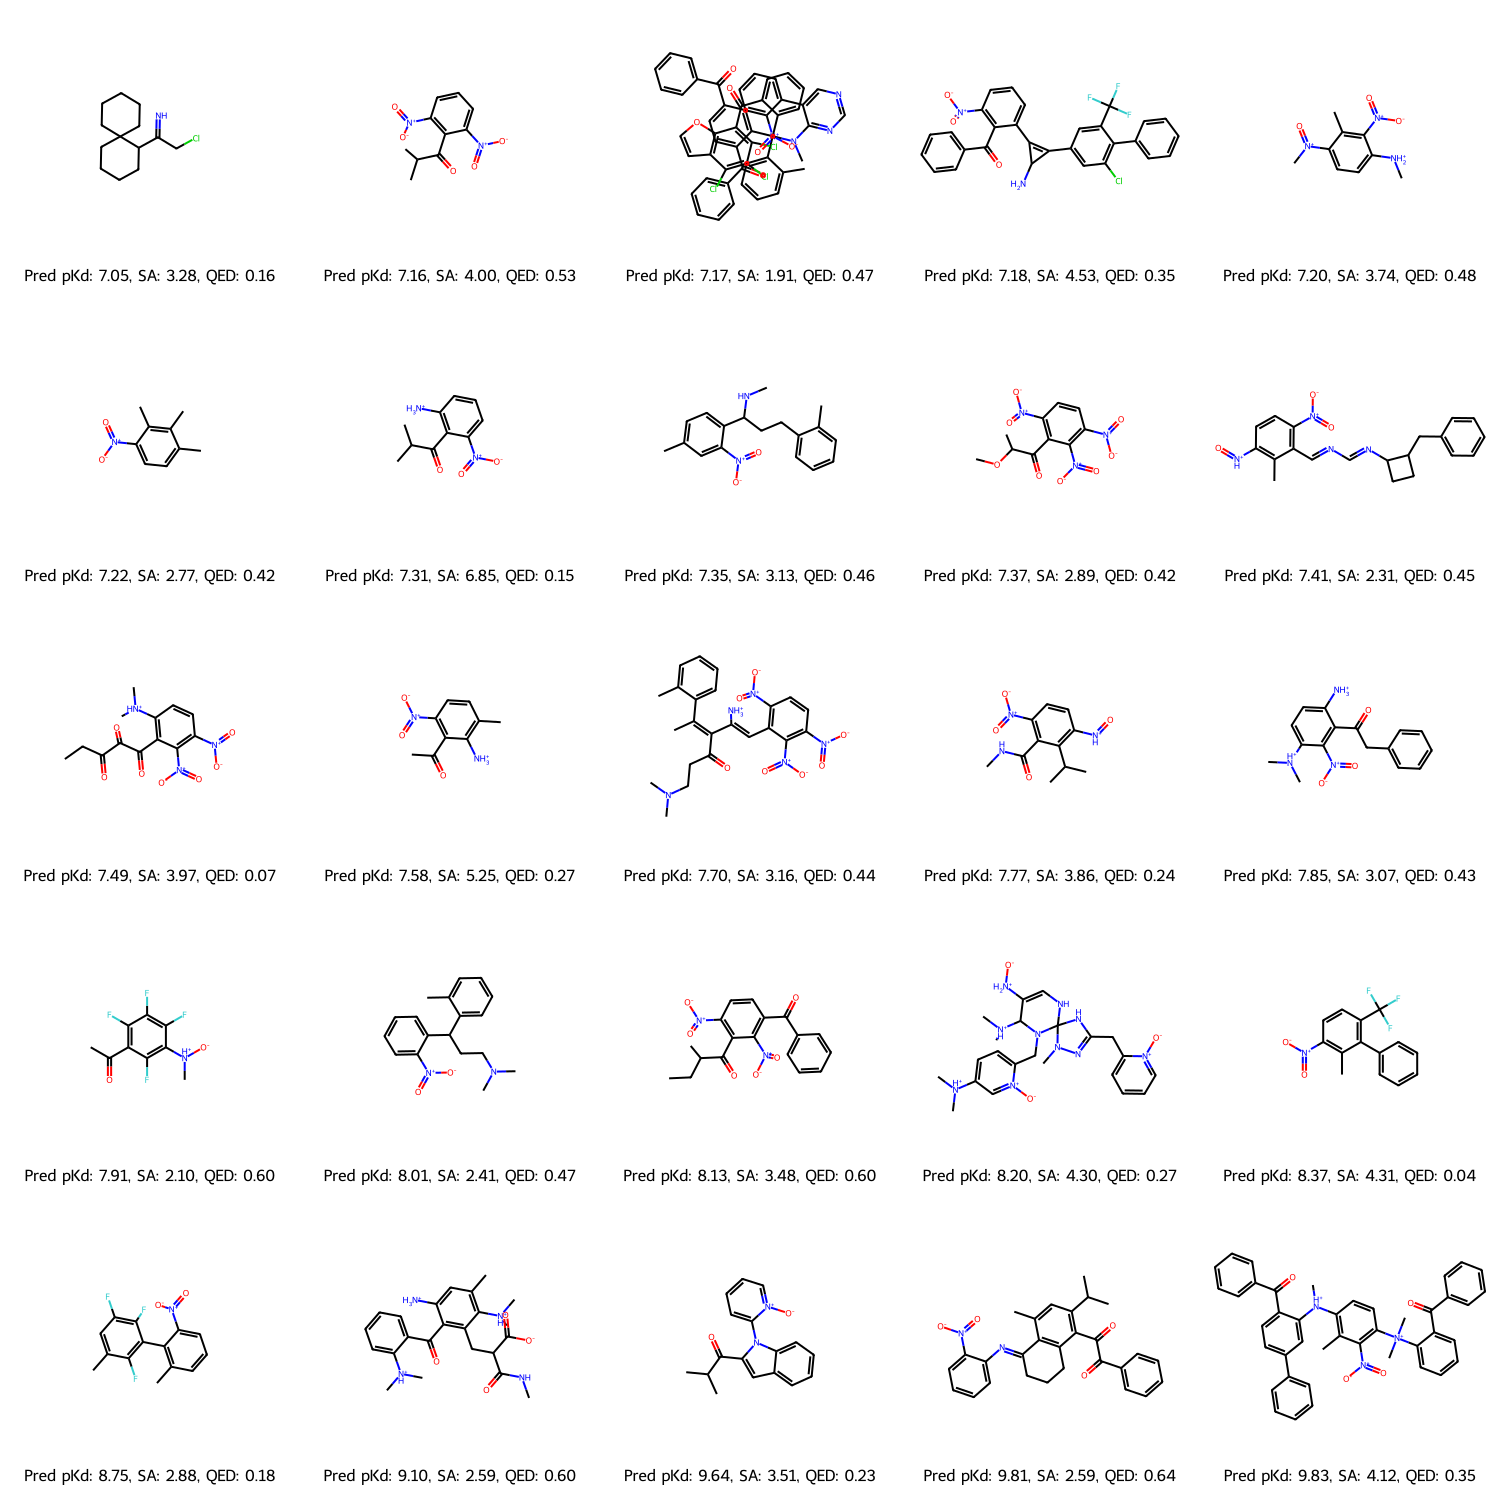

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Convert all SMILES to RDKit Mol objects
mols = [Chem.MolFromSmiles(sm) for sm in best_smiles_sorted]

# Optionally, annotate each molecule with its predicted QED
legends = [f'Pred pKd: {best_binding_score_sorted[i]:.2f}, SA: {10*(1-best_sa[i]):.2f}, QED: {best_qed[i]:.2f}' for i in range(len(best_binding_score))] #I changed the name to multi-objective reward, can be changed

# Plot them in a grid
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=5,    # You can adjust this (5 molecules per row)
    subImgSize=(300,300),  # Size of each molecule image
    legends=legends,       # Small text under each molecule
    useSVG=False           # Set to True if you want a SVG output
)

# Display the grid
img

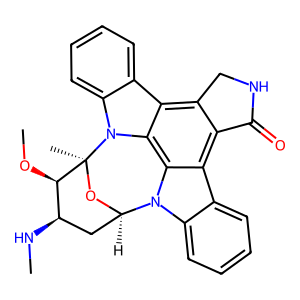

In [ ]:
# Plot Staurosporine

# Convert all SMILES to RDKit Mol objects
mol_staurosporine = Chem.MolFromSmiles(staurosporine_smiles[0])
img_single_plot = Draw.MolToImage(mol_staurosporine)
img_single_plot


# Some nicer plots

In the following, we write some minimal code to compare our model results against random baseline.

In [ ]:
##### Get baseline PPO for Plotting

#loop for n epoch (100?)
vae_model.eval()
scoring_model.eval()
average_obj_scores_baseline = []
best_z_list_baseline = []
best_reward_list_baseline = []

for epoch in range(n_epochs):

    # 1. Random sampling
    z_next = torch.randn(batch_size, 3*latent_dim).to(device)

    # 2. Decode
    z_next_to_decode = torch.chunk(z_next, 3, dim=1)
    smiles_batch, valid = safe_decode_batch(vae_model.decoder, z_next_to_decode)

    valid_mask = torch.tensor(valid, device=device, dtype=torch.bool)
    valid_smiles = [smile for smile, is_valid in zip(smiles_batch, valid) if is_valid]

    # 3. Initialize rewards
    un_norm_rewards = torch.zeros(batch_size, device=device)
    un_norm_rewards[~valid_mask] = penalty_value

    if len(valid_smiles) > 0:
        sa, qed = sa_and_qed_rewards(valid_smiles)
        w = 0.1
        bs = compute_prop_high_binders(scoring_model, valid_smiles, target_protein)

        # un_norm_rewards[valid_mask] = w * sa + w * qed + (1.0 - 2*w) * bs
        un_norm_rewards[valid_mask] = bs

    # 4. Normalize rewards
    rewards = (un_norm_rewards - un_norm_rewards.mean()) / (un_norm_rewards.std() + 1e-8)

    # 5. Save best z found in this batch
    best_idx = un_norm_rewards.argmax()
    best_reward_now = un_norm_rewards[best_idx]
    best_z_now = z_next[best_idx:best_idx+1].clone().detach()

    best_z_list_baseline.append(best_z_now)
    best_reward_list_baseline.append(best_reward_now.item())

    # 6. Keep only the top N_best
    if len(best_z_list) > N_best:
        sorted_indices = sorted(range(len(best_reward_list_baseline)), key=lambda i: best_reward_list_baseline[i], reverse=True)
        best_z_list_baseline = [best_z_list_baseline[i] for i in sorted_indices[:N_best]]
        best_reward_list_baseline = [best_reward_list_baseline[i] for i in sorted_indices[:N_best]]

    # 7. Logging
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Avg reward = {un_norm_rewards.mean().item():.4f}")

    # 8. Save average score per epoch
    average_obj_scores_baseline.append(un_norm_rewards.mean().item())


Epoch 0: Avg reward = 0.0000
Epoch 5: Avg reward = 0.0000
Epoch 10: Avg reward = 0.0312
Epoch 15: Avg reward = 0.0156
Epoch 20: Avg reward = 0.0156
Epoch 25: Avg reward = 0.0234
Epoch 30: Avg reward = 0.0000
Epoch 35: Avg reward = 0.0000
Epoch 40: Avg reward = 0.0078
Epoch 45: Avg reward = 0.0000
Epoch 50: Avg reward = 0.0156
Epoch 55: Avg reward = 0.0000
Epoch 60: Avg reward = 0.0156
Epoch 65: Avg reward = 0.0156
Epoch 70: Avg reward = 0.0078
Epoch 75: Avg reward = 0.0156
Epoch 80: Avg reward = 0.0078
Epoch 85: Avg reward = 0.0000
Epoch 90: Avg reward = 0.0156
Epoch 95: Avg reward = 0.0000


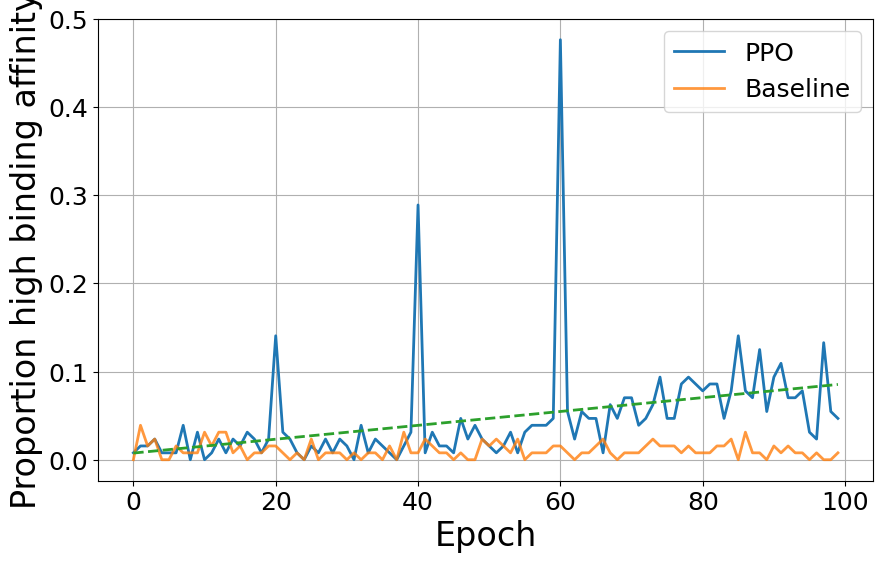

Slope of best fit line: 0.0008


In [ ]:
###### Plot with Pres Formatting

import matplotlib.pyplot as plt
import numpy as np

# Example: average_obj_scores = [your list of scores here]

# Create x values (epochs)
epochs = np.arange(len(average_obj_scores))

# Fit a line (y = m*x + b)
slope, intercept = np.polyfit(epochs, average_obj_scores, deg=1)

# Now generate the fitted line
best_fit_line = slope * epochs + intercept

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, average_obj_scores, label = 'PPO', linewidth=2)
plt.plot(epochs, average_obj_scores_baseline, label='Baseline', linewidth=2, alpha=0.8)
plt.plot(epochs, best_fit_line, label="", linestyle='--', linewidth=2)
plt.xlabel('Epoch', fontsize=24)
plt.ylabel('Proportion high binding affinity', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.legend(fontsize=18)
plt.show()

# Print slope value
print(f"Slope of best fit line: {slope:.4f}")